In [4]:
import serial
import numpy as np
import time
from matplotlib import pyplot as plt
from ribbn_scripts.hardware_api.hardware import Exciter,Tag
import multiprocessing

In [2]:
# com_port1="COM4"
com_port1="/dev/tty.usbserial-1140"
# try:
#     ser1 = serial.Serial(port=com_port1, baudrate=512000, parity=serial.PARITY_NONE,
#                 stopbits=serial.STOPBITS_ONE, bytesize=serial.EIGHTBITS, timeout=0)
# except Exception as e:
#     print("Couldn't connect.", e)
tag1=Tag(com_port1)
print(tag1.get_mac())

# com_port2="COM5"
com_port2="/dev/tty.usbserial-1130"
# try:
#     ser2 = serial.Serial(port=com_port2, baudrate=512000, parity=serial.PARITY_NONE,
#                 stopbits=serial.STOPBITS_ONE, bytesize=serial.EIGHTBITS, timeout=0)
# except Exception as e:
#     print("Couldn't connect.", e)
tag2=Tag(com_port2)
print(tag2.get_mac())


b'00:00:00:00:00:00\r\n'
b'00:00:00:00:00:00\r\n'


In [5]:
def device_worker(com_port, tag_id, command_queue, result_queue):
    """
    A worker function to be run in a separate PROCESS. It instantiates its
    own Tag object to avoid sharing non-serializable objects.
    """
    print(f"Process for Tag {tag_id} on {com_port} started.")
    # Each process creates its own instance of the Tag class
    tag_instance = Tag(com_port)
    
    while True:
        try:
            command = command_queue.get()

            if command == "STOP":
                tag_instance.disconnect()
                print(f"Process for Tag {tag_id} stopping.")
                break
            
            if command == "get_mac":
                result = tag_instance.get_mac()
                result_queue.put((tag_id, "mac", result))
            elif command == "begin_reading":
                tag_instance.begin_reading()
            elif command == "perform_mpp":
                result = tag_instance.perform_mpp()
                result_queue.put((tag_id, "mpp_times", result))
            elif command == "stop_reading":
                result = tag_instance.stop_reading()
                result_queue.put((tag_id, "voltage_readings", result))
            elif command == "get_adc_val":
                result = tag_instance.get_adc_val()
                result_queue.put((tag_id, "adc_vals", result))
            elif command[:2]=='ch':
                tag_instance.reflect(command.encode())

        except Exception as e:
            print(f"🛑 ERROR in process for Tag {tag_id} ({com_port}): {e}")
            continue


In [6]:
cmd_q1, cmd_q2, cmd_q3, result_q, process1, process2, process3\
    =None, None, None, None, None, None, None
def initialize(TAG1_COM, TAG2_COM):
    global cmd_q1, cmd_q2, cmd_q3, result_q, process1, process2, process3
    
    # Create queues from the multiprocessing module
    cmd_q1 = multiprocessing.Queue()
    cmd_q2 = multiprocessing.Queue()
    # cmd_q3 = multiprocessing.Queue()
    result_q = multiprocessing.Queue()

    process1 = multiprocessing.Process(target=device_worker, args=(TAG1_COM, 1, cmd_q1, result_q), daemon=True)
    process2 = multiprocessing.Process(target=device_worker, args=(TAG2_COM, 2, cmd_q2, result_q), daemon=True)
    # process3 = multiprocessing.Process(target=device_worker, args=(TAG3_COM, 2, cmd_q3, result_q), daemon=True)

    # Start the child processes
    process1.start()
    process2.start()
    # process3.start

In [9]:
initialize(com_port1, com_port2)

Traceback (most recent call last):
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/usr/local/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
  File "<string>", line 1, in <module>
  File "/usr/local/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
    exitcode = _main(fd, parent_sentinel)
                        ^ ^ ^ ^ ^ ^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^^^^  File "/usr/local/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
^^
  File "/usr/local/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
    self = reduction.pickle.load

Begin reading
Starting MPP
Reading response
could not convert string to float: ''
Begin reading
Starting MPP
Reading response
could not convert string to float: ''
Begin reading
Starting MPP
Reading response
could not convert string to float: ''
Begin reading
Starting MPP
Reading response
could not convert string to float: ''
Begin reading
Starting MPP
Reading response
could not convert string to float: ''


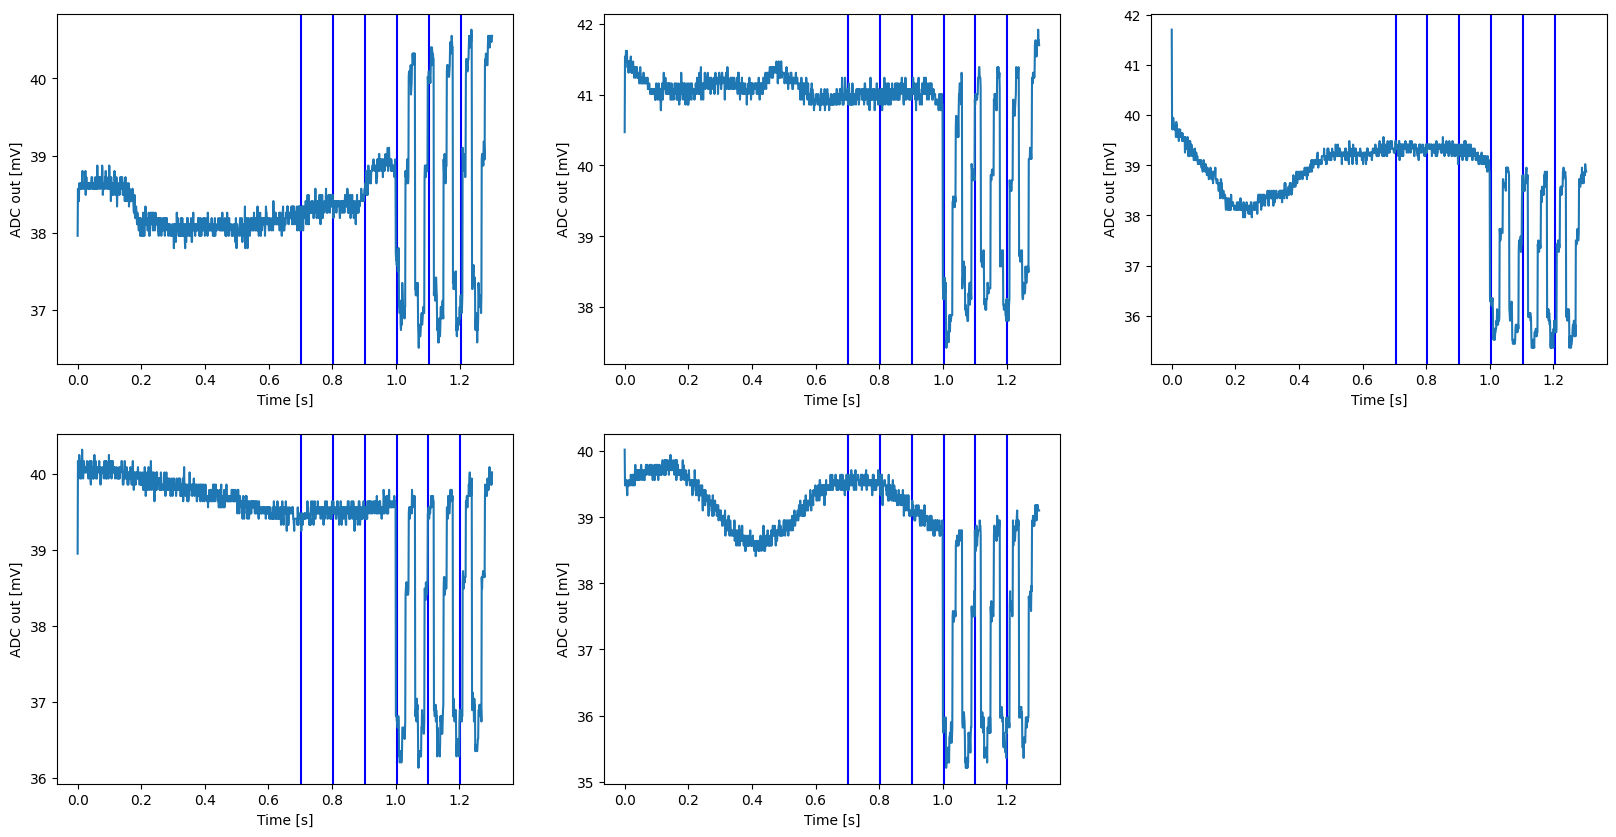

In [ ]:
plt.figure(figsize=(20,10))
for rep in range(5):
    plt.subplot(2,3,rep+1)
    print("Begin reading")     
    
    tag1.begin_reading()

    print("Starting MPP")     
    
    mpp_start_time,mpp_stop_time=tag2.perform_mpp()

    print("Reading response")
    # ser1.write(b"rds\0\n")
    # time.sleep(0.1)
    # voltages=""

    # read_start_time=time.time()
    # while True:
    #     if time.time()-read_start_time>5: #run max for 20 seconds
    #         break
    #     line = ser1.readline()
    #     if len(line) > 0:
    #         # ss = str(line)
    #         ss = str(line)
    #         print(ss)
            
    #         if "end" in ss:
    #             break
    #         try:
    #             to_add=line.decode()
    #             to_add=to_add.replace("\n",'')
    #             to_add=to_add.replace("\r",'')
    #             voltages+=to_add
    #         except Exception as e:
    #             print(e)
    voltage_readings=tag1.stop_reading()

    mpp_time_elapsed=mpp_stop_time-mpp_start_time
    plot_all_time=np.arange(0,mpp_time_elapsed,mpp_time_elapsed/len(voltage_readings))
    plot_end_time=plot_all_time[-1]
    ver_lines=[]
    for i in range(6):
        ver_lines.append(plot_end_time-0.1*(i+1))

    for v in ver_lines:
        plt.axvline(x = v, color = 'b', label = 'axvline - full height')

    plt.plot(np.arange(0,mpp_time_elapsed,mpp_time_elapsed/len(voltage_readings))[:len(voltage_readings)],voltage_readings)

    plt.xlabel("Time [s]")
    plt.ylabel("ADC out [mV]")

In [76]:
len(voltage_readings)

1761

In [77]:
tag1.disconnect()
tag2.disconnect()

In [78]:
# def clean_voltage_data(voltages):
#     data=voltages.split(',')
#     max_num=int(data[0])
#     data=data[1:]
#     clean_data=[]
#     for d in data:
#         try:
#             clean_data.append(float(d))
#         except Exception as e:
#             print(e)
#     assert(len(clean_data)<=max_num)
    
#     return np.array(clean_data)


In [79]:
import pickle

df=pickle.load(open("C:/Users/Manavjeet Singh/Git/T2TExperiments/Experiments/EstimatingDistSamirOffice/dataframes/0.df","br"))

In [80]:
df.to_csv("deleme.csv")